# House Price Prediction - Complete ML Pipeline
**Kernel: ml_env**

## 1. Import Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import pickle, os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Data

In [39]:
df = pd.read_csv('House Price.csv')
print('Shape:', df.shape)
df.head()

Shape: (29451, 12)


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  object 
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  object 
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  object 
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.7+ MB


In [41]:
df.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


## 3. Exploratory Data Analysis (EDA)

In [42]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [43]:
# Duplicate rows
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 401
Shape after removing duplicates: (29050, 12)


In [44]:
# Categorical columns unique values
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

POSTED_BY: ['Owner' 'Dealer' 'Builder']
BHK_OR_RK: ['BHK' 'RK']
ADDRESS: ['Ksfc Layout,Bangalore' 'Vishweshwara Nagar,Mysore' 'Jigani,Bangalore'
 ... 'west mambalam,Chennai' 'Gandhi Nagar,Gulbarga'
 'E3-108, Lake View Recidency,,Vapi']


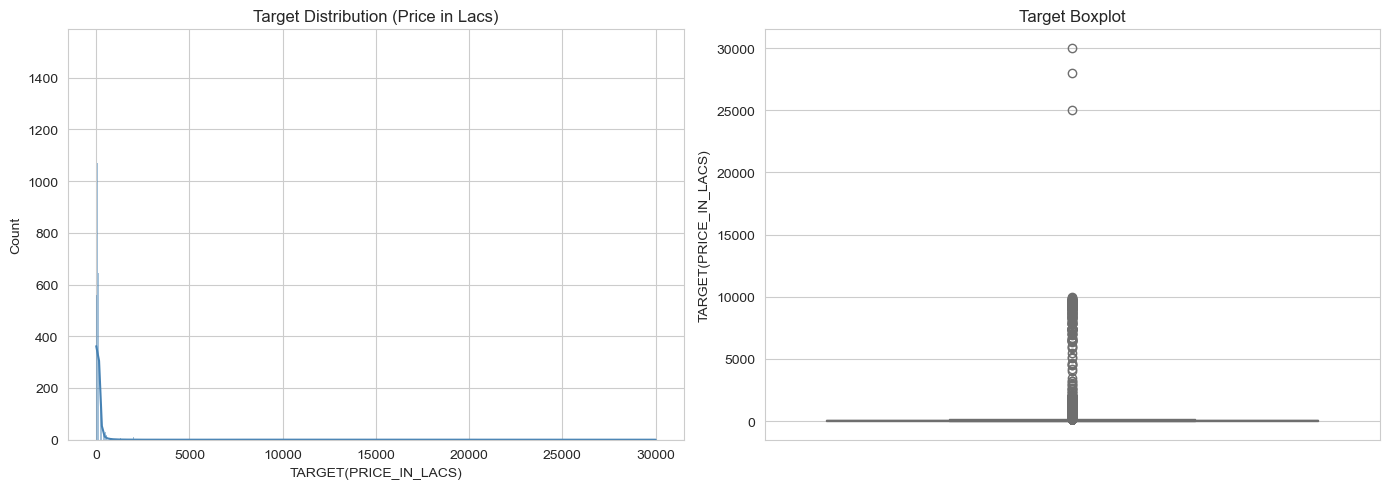

In [45]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['TARGET(PRICE_IN_LACS)'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Target Distribution (Price in Lacs)')
sns.boxplot(y=df['TARGET(PRICE_IN_LACS)'], ax=axes[1], color='lightcoral')
axes[1].set_title('Target Boxplot')
plt.tight_layout(); plt.show()

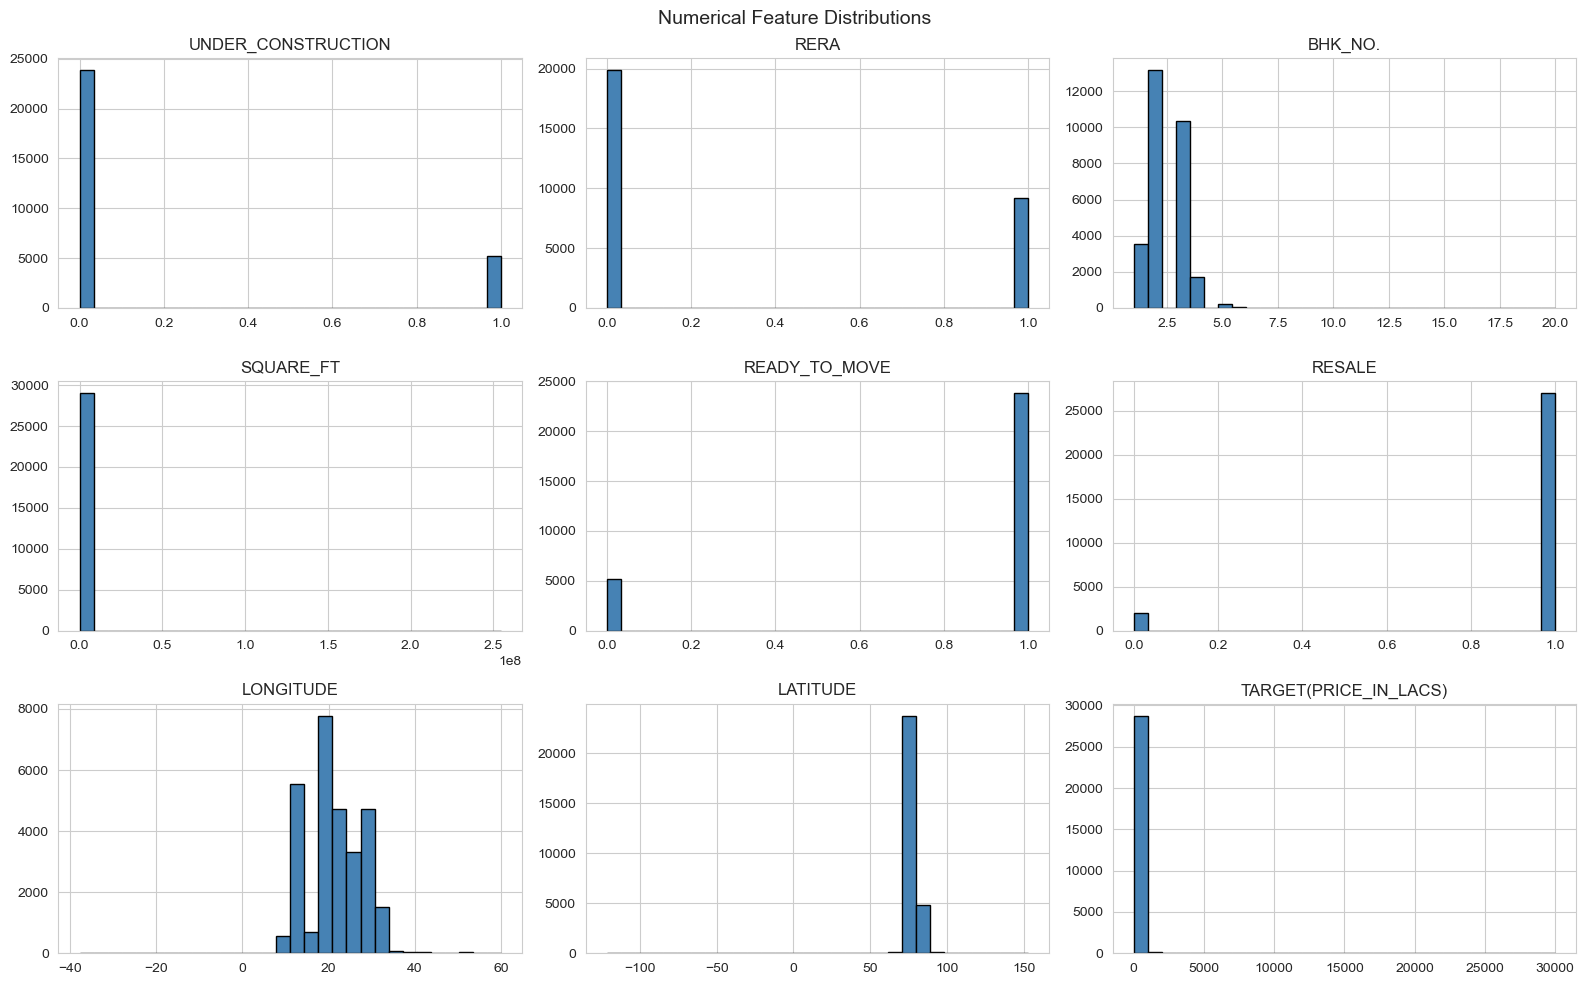

In [46]:
# Numerical feature distributions
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(bins=30, figsize=(16, 10), color='steelblue', edgecolor='black')
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout(); plt.show()

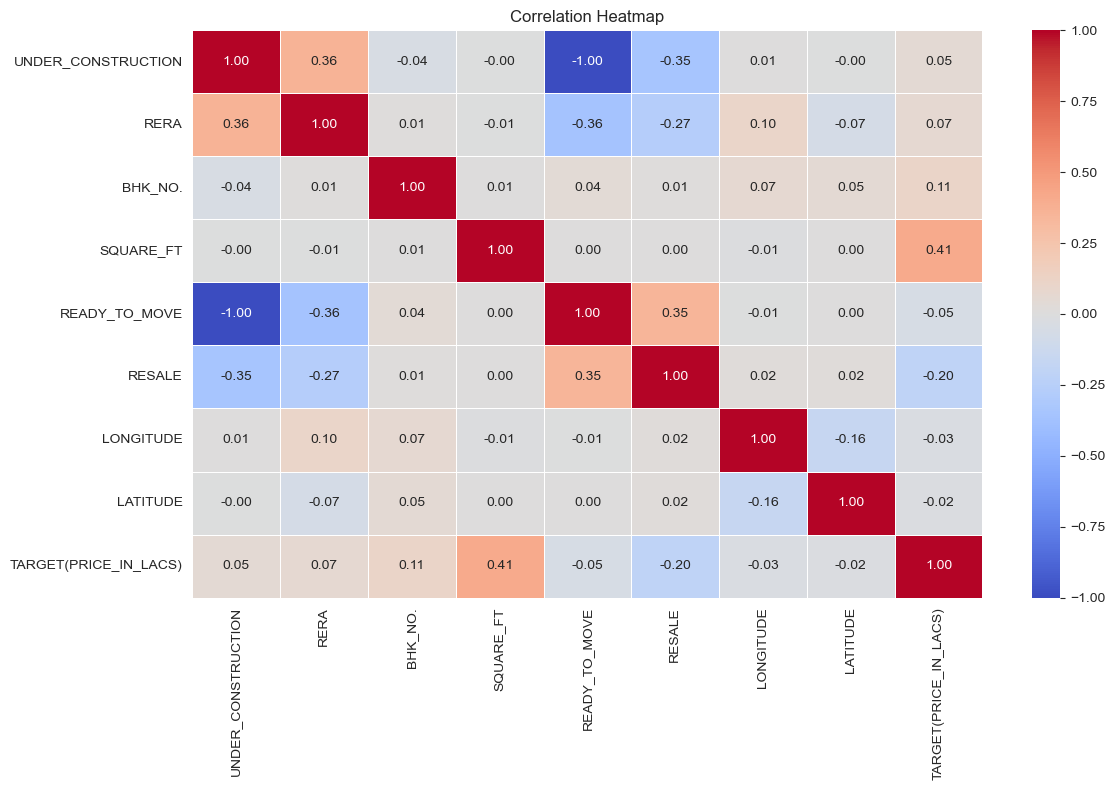

In [47]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

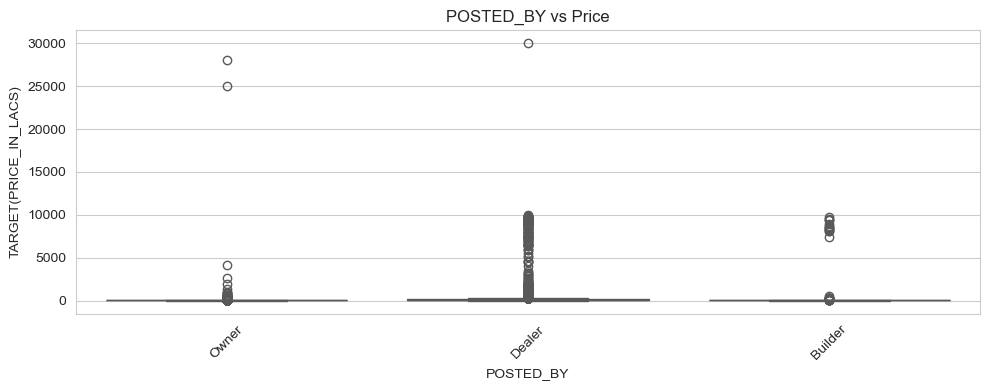

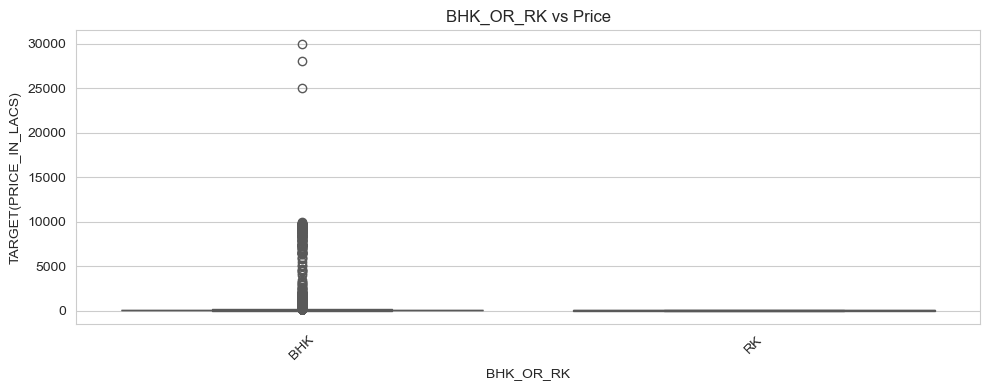

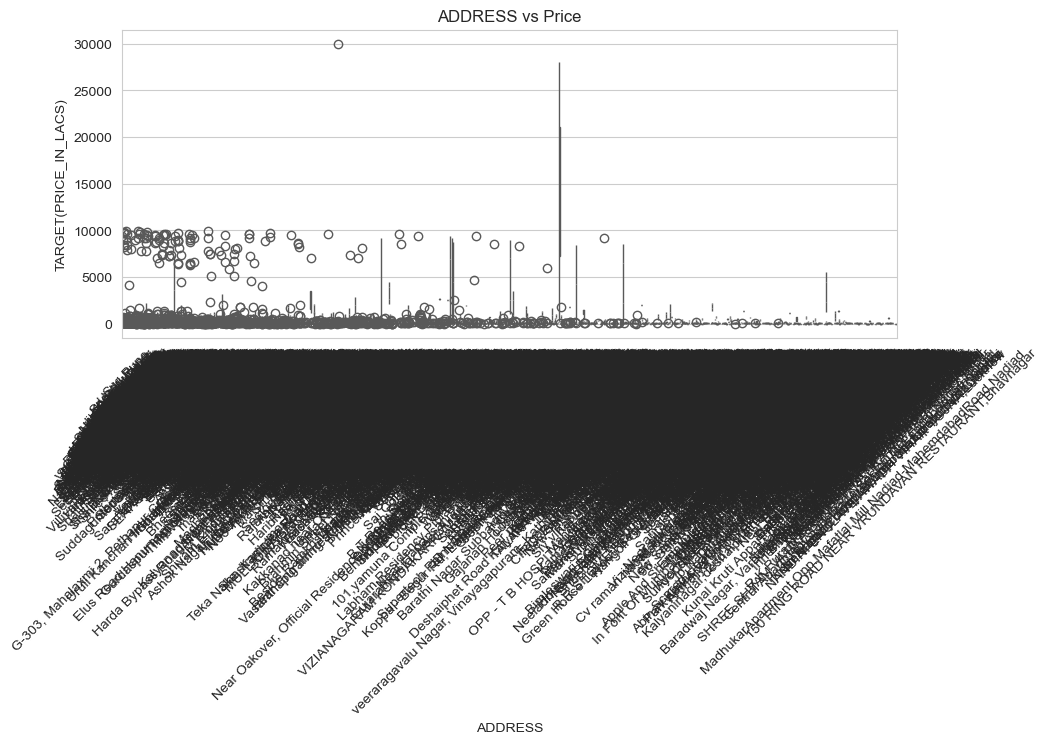

In [48]:
# Categorical feature vs Target
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], y=df['TARGET(PRICE_IN_LACS)'], palette='Set2')
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

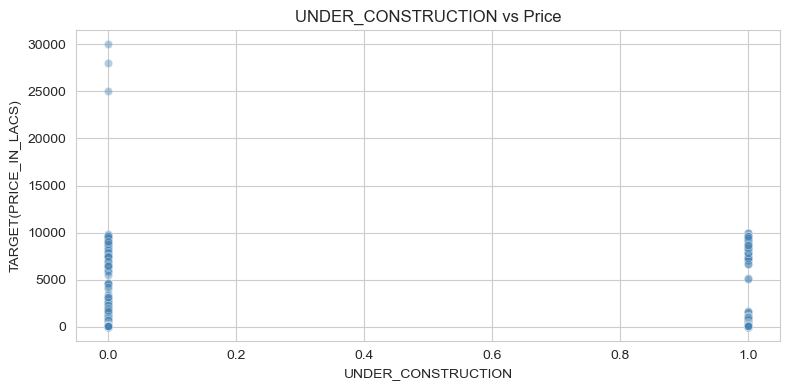

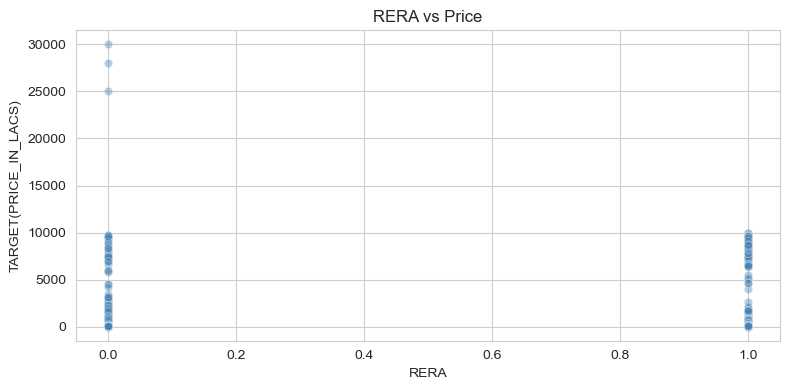

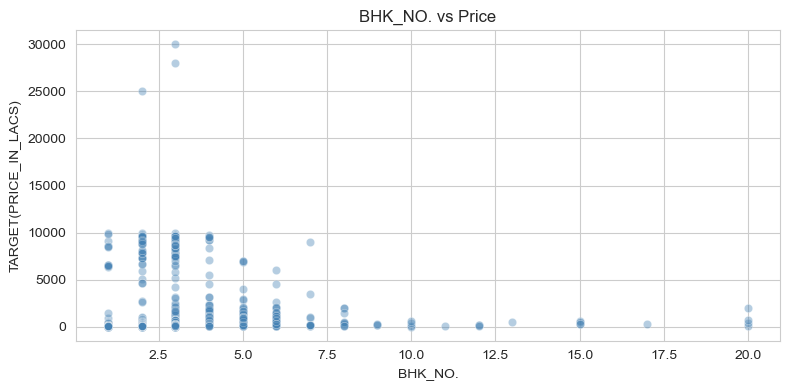

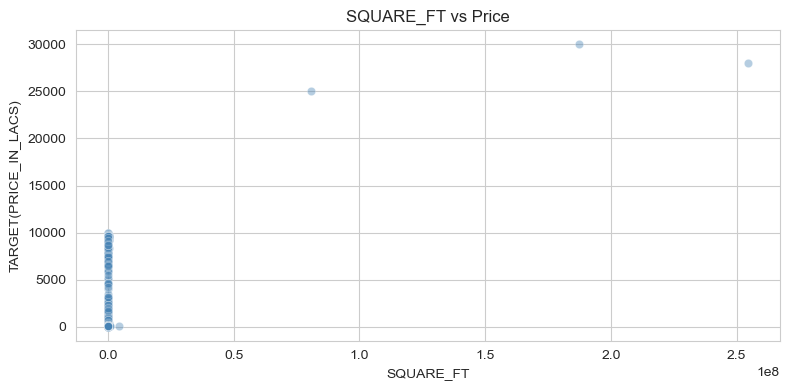

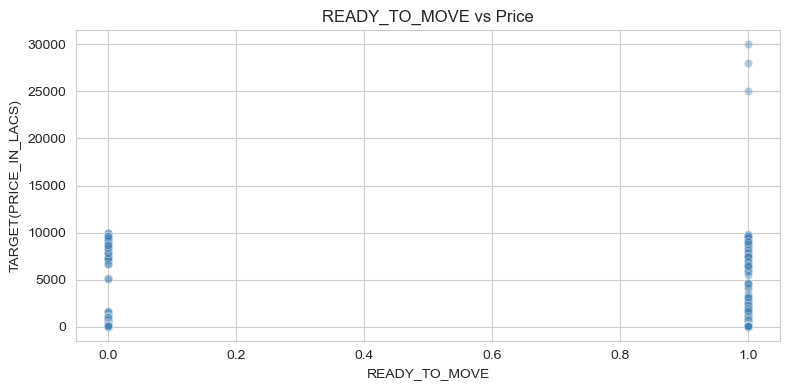

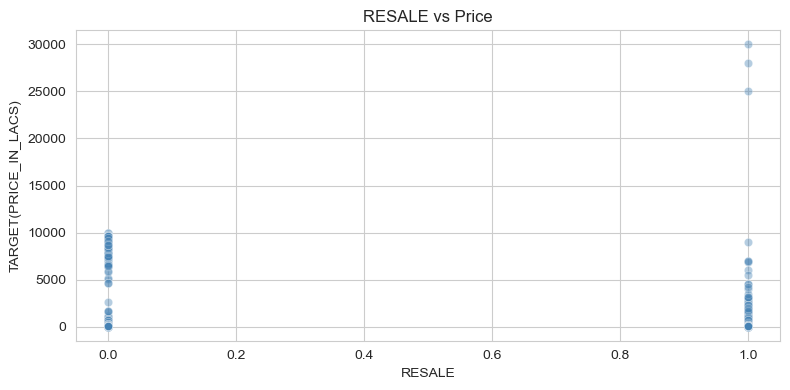

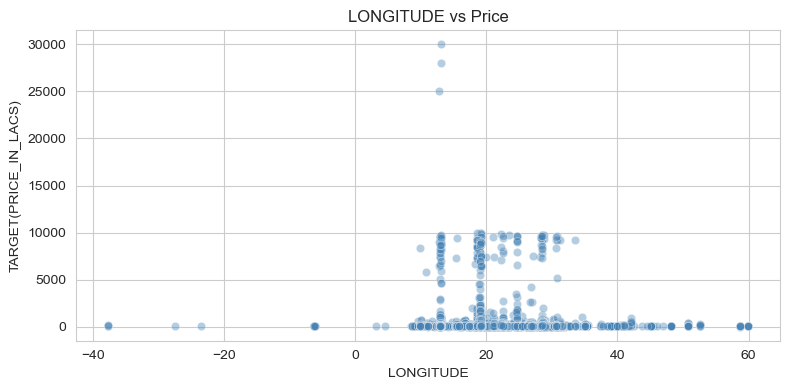

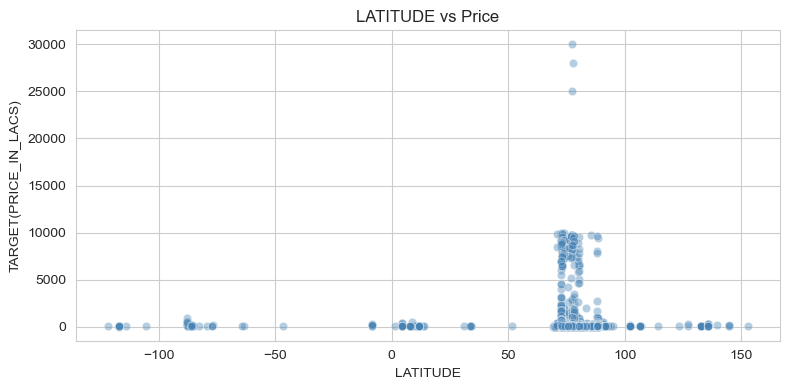

In [50]:
# Scatter plots: numerical features vs target
num_features = [c for c in num_cols if c != 'TARGET(PRICE_IN_LACS)']
for col in num_features:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=df[col], y=df['TARGET(PRICE_IN_LACS)'], alpha=0.4, color='steelblue')
    plt.title(f'{col} vs Price')
    plt.tight_layout(); plt.show()

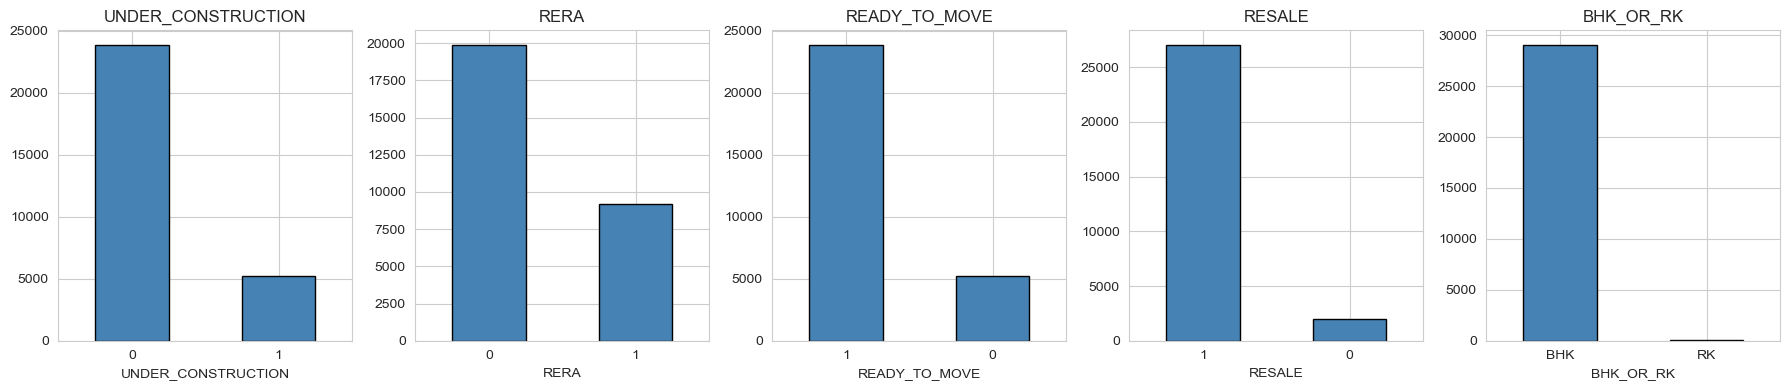

In [51]:
# Count plots for binary/categorical columns
binary_cols = ['UNDER_CONSTRUCTION', 'RERA', 'READY_TO_MOVE', 'RESALE', 'BHK_OR_RK']
fig, axes = plt.subplots(1, len(binary_cols), figsize=(18, 4))
for i, col in enumerate(binary_cols):
    if col in df.columns:
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 4. Feature Engineering

In [52]:
# Price per square foot
df['PRICE_PER_SQFT'] = df['TARGET(PRICE_IN_LACS)'] / df['SQUARE_FT']

# BHK_OR_RK: binary encode (BHK=1, RK=0)
df['IS_BHK'] = (df['BHK_OR_RK'] == 'BHK').astype(int)

# POSTED_BY: label encode
le = LabelEncoder()
df['POSTED_BY_ENC'] = le.fit_transform(df['POSTED_BY'])
posted_by_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('POSTED_BY mapping:', posted_by_mapping)

# Extract CITY from ADDRESS
df['CITY'] = df['ADDRESS'].apply(lambda x: x.split(',')[-1].strip() if isinstance(x, str) else 'Unknown')
print(f'Total unique cities: {df["CITY"].nunique()}')
print('Top 10 cities by count:')
print(df['CITY'].value_counts().head(10))

POSTED_BY mapping: {'Builder': np.int64(0), 'Dealer': np.int64(1), 'Owner': np.int64(2)}
Total unique cities: 256
Top 10 cities by count:
CITY
Bangalore      4272
Lalitpur       2963
Mumbai         2006
Pune           1980
Noida          1718
Kolkata        1686
Maharashtra    1571
Chennai        1245
Ghaziabad      1070
Jaipur          950
Name: count, dtype: int64


Target encoding done → CITY_TARGET_ENC (mean price per city)
Frequency encoding done → CITY_FREQ_ENC (relative frequency per city)


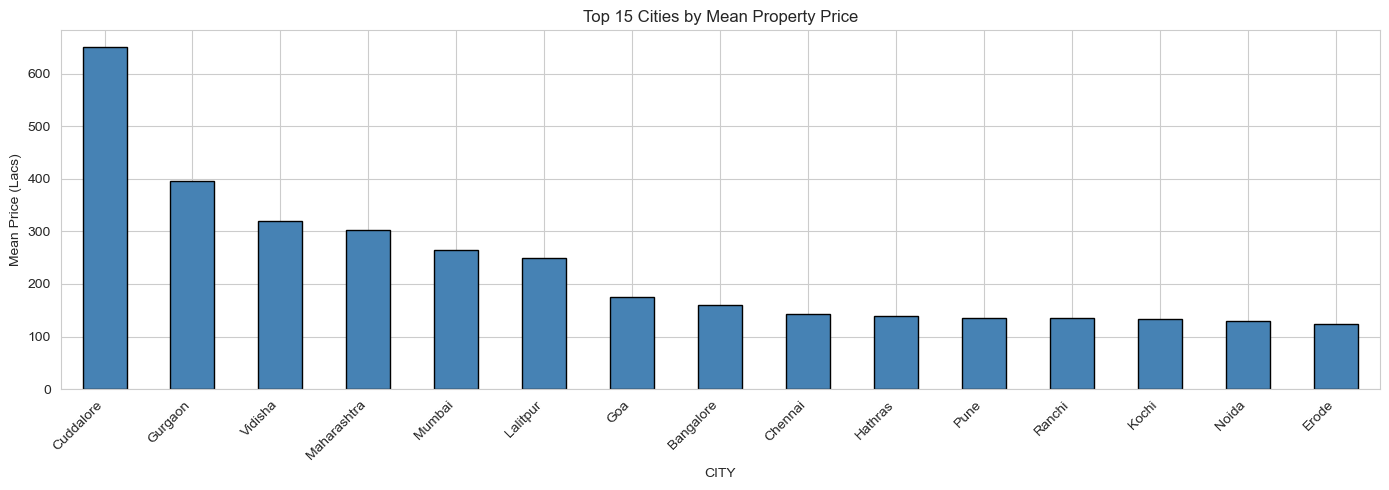

,CITY,CITY_TARGET_ENC,CITY_FREQ_ENC
26047,Cuddalore,650.000000,0.000034
120,Gurgaon,396.777566,0.014423
10780,Vidisha,320.000000,0.000034
34,Maharashtra,302.282304,0.054079
23,Mumbai,264.987139,0.069053
33,Lalitpur,249.490820,0.101997
554,Goa,175.785906,0.005129
0,Bangalore,159.617130,0.147057
9,Chennai,142.177590,0.042857
9515,Hathras,140.000000,0.000034


In [53]:
# ── Target Encoding for CITY ──────────────────────────────────────────────────
# Replace city with its mean target price — directly captures price signal per city
city_target_mean = df.groupby('CITY')['TARGET(PRICE_IN_LACS)'].mean()
global_mean = df['TARGET(PRICE_IN_LACS)'].mean()
df['CITY_TARGET_ENC'] = df['CITY'].map(city_target_mean).fillna(global_mean)
print('Target encoding done → CITY_TARGET_ENC (mean price per city)')

# ── Frequency Encoding for CITY ───────────────────────────────────────────────
# Replace city with its relative frequency — captures city popularity/activity
city_freq = df['CITY'].value_counts(normalize=True)
df['CITY_FREQ_ENC'] = df['CITY'].map(city_freq).fillna(0)
print('Frequency encoding done → CITY_FREQ_ENC (relative frequency per city)')

# Top 15 cities by mean price
plt.figure(figsize=(14, 5))
city_target_mean.sort_values(ascending=False).head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Cities by Mean Property Price')
plt.ylabel('Mean Price (Lacs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

df[['CITY','CITY_TARGET_ENC','CITY_FREQ_ENC']].drop_duplicates().sort_values('CITY_TARGET_ENC', ascending=False).head(10)

## 5. Outlier Treatment (IQR Capping — No Deletion)

In [54]:
outlier_cols = ['SQUARE_FT', 'TARGET(PRICE_IN_LACS)', 'BHK_NO.', 'PRICE_PER_SQFT']

def cap_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df[col] = np.clip(df[col], lower, upper)
    print(f'{col:30s} → lower: {lower:.2f}  upper: {upper:.2f}')
    return df

for col in outlier_cols:
    df = cap_outliers(df, col)
print('\nOutlier capping done (no rows deleted).')

SQUARE_FT                      → lower: -75.25  upper: 2525.42
TARGET(PRICE_IN_LACS)          → lower: -55.00  upper: 193.00
BHK_NO.                        → lower: 0.50  upper: 4.50
PRICE_PER_SQFT                 → lower: -0.03  upper: 0.15

Outlier capping done (no rows deleted).


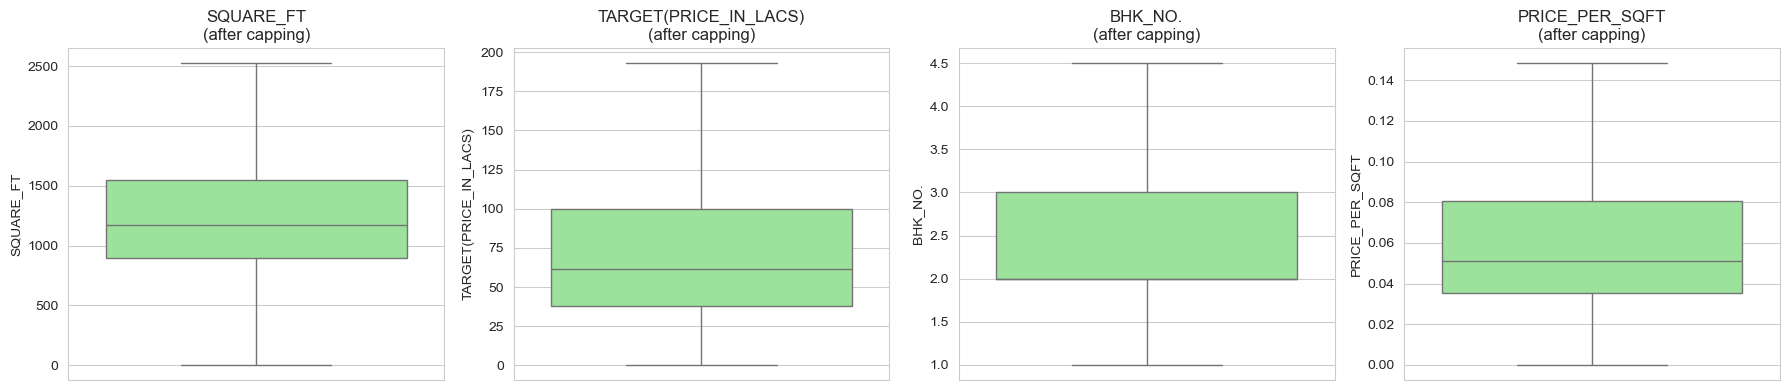

In [55]:
# Boxplots after capping
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col}\n(after capping)')
plt.tight_layout(); plt.show()

## 6. Skewness Removal

In [56]:
skew_cols = ['SQUARE_FT', 'TARGET(PRICE_IN_LACS)', 'PRICE_PER_SQFT']

print('Skewness BEFORE:')
for col in skew_cols:
    print(f'  {col}: {df[col].skew():.4f}')

for col in skew_cols:
    if df[col].skew() > 0.5:
        df[col] = np.log1p(df[col])

print('\nSkewness AFTER log1p:')
for col in skew_cols:
    print(f'  {col}: {df[col].skew():.4f}')

Skewness BEFORE:
  SQUARE_FT: 0.7407
  TARGET(PRICE_IN_LACS): 0.9598
  PRICE_PER_SQFT: 1.0623

Skewness AFTER log1p:
  SQUARE_FT: -0.7941
  TARGET(PRICE_IN_LACS): -0.1368
  PRICE_PER_SQFT: 1.0153


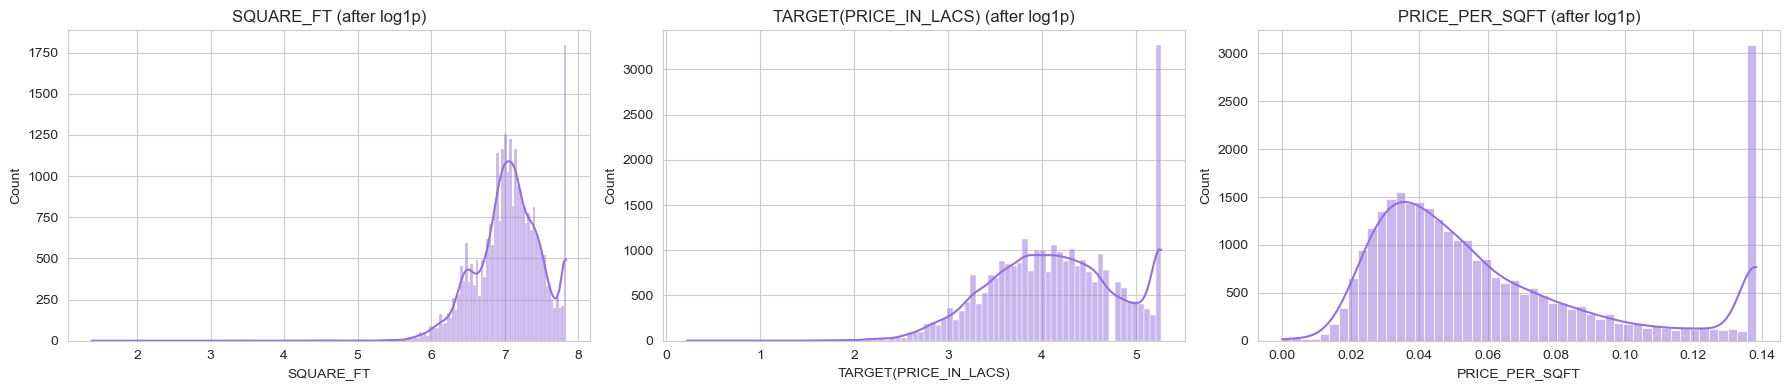

In [57]:
fig, axes = plt.subplots(1, len(skew_cols), figsize=(18, 4))
for i, col in enumerate(skew_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='mediumpurple')
    axes[i].set_title(f'{col} (after log1p)')
plt.tight_layout(); plt.show()

## 7. Remove Unnecessary Columns

In [ ]:
# ADDRESS     → raw string, already used to extract CITY
# BHK_OR_RK   → already encoded as IS_BHK
# POSTED_BY   → already encoded as POSTED_BY_ENC
# CITY        → raw string, already encoded as CITY_TARGET_ENC & CITY_FREQ_ENC
drop_cols = ['ADDRESS', 'BHK_OR_RK', 'POSTED_BY', 'CITY','READY_TO_MOVE']
df.drop(columns=drop_cols, inplace=True)

print('Remaining columns:', df.columns.tolist())
df.head()

KeyError: "['ADDRESS', 'BHK_OR_RK', 'POSTED_BY', 'CITY'] not found in axis"

In [70]:
df.drop(columns='UNDER_CONSTRUCTION',inplace=True)

## 8. Define Input and Output Features

In [71]:
X = df.drop(columns=['TARGET(PRICE_IN_LACS)'])
y = df['TARGET(PRICE_IN_LACS)']

print('Input features :', X.columns.tolist())
print('Output feature : TARGET(PRICE_IN_LACS)')
print('X shape:', X.shape, '  y shape:', y.shape)

Input features : ['RERA', 'BHK_NO.', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'PRICE_PER_SQFT', 'IS_BHK', 'POSTED_BY_ENC', 'CITY_TARGET_ENC', 'CITY_FREQ_ENC']
Output feature : TARGET(PRICE_IN_LACS)
X shape: (29050, 12)   y shape: (29050,)


## 9. Feature Scaling

In [72]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print('Feature scaling done using StandardScaler.')
X_scaled.describe()

Feature scaling done using StandardScaler.


,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,PRICE_PER_SQFT,IS_BHK,POSTED_BY_ENC,CITY_TARGET_ENC,CITY_FREQ_ENC
count,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04,2.905000e+04
mean,-3.766733e-17,2.676459e-16,-1.511096e-15,-9.612506e-17,7.203265e-17,-3.321573e-16,-5.381047e-18,1.359937e-16,1.858907e-15,6.677390e-17,1.854015e-16,3.032954e-17
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00
min,-6.794915e-01,-1.731340e+00,-1.263666e+01,-2.141871e+00,-3.655114e+00,-9.519779e+00,-1.879280e+01,-1.713637e+00,-3.477667e+01,-2.592863e+00,-1.570568e+00,-1.235474e+00
25%,-6.794915e-01,-4.732780e-01,-5.502835e-01,4.668814e-01,2.735892e-01,-4.547563e-01,-2.871840e-01,-7.431850e-01,2.875491e-02,-6.565973e-01,-9.310708e-01,-8.658016e-01
50%,-6.794915e-01,-4.732780e-01,3.972512e-02,4.668814e-01,2.735892e-01,-1.030914e-01,4.668021e-02,-3.297394e-01,2.875491e-02,-6.565973e-01,-8.325409e-02,-9.297093e-03
75%,1.471689e+00,7.847836e-01,6.617850e-01,4.668814e-01,2.735892e-01,9.065090e-01,1.025181e-01,4.444263e-01,2.875491e-02,1.279668e+00,2.061404e-01,2.235673e-01
max,1.471689e+00,2.671876e+00,1.750109e+00,4.668814e-01,2.735892e-01,6.236837e+00,7.204531e+00,2.135899e+00,2.875491e-02,1.279668e+00,5.852095e+00,1.872539e+00


## 10. Train-Test Split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print('Train size:', X_train.shape)
print('Test  size:', X_test.shape)

Train size: (23240, 12)
Test  size: (5810, 12)


## 11. Model Training & Evaluation (All Regression Models)

In [74]:
models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Lasso Regression'   : Lasso(alpha=0.01),
    'ElasticNet'         : ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Decision Tree'      : DecisionTreeRegressor(random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost'           : AdaBoostRegressor(n_estimators=100, random_state=42),
    #'Extra Trees'        : ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Bagging Regressor'  : BaggingRegressor(n_estimators=100, random_state=42),
    'KNN Regressor'      : KNeighborsRegressor(n_neighbors=5),
    'SVR'                : SVR(kernel='rbf'),
    'XGBoost'            : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM'           : LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

n_train, n_test, k = X_train.shape[0], X_test.shape[0], X_train.shape[1]

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # Train
    y_tr_pred    = model.predict(X_train)
    r2_train     = r2_score(y_train, y_tr_pred)
    adjr2_train  = adjusted_r2(r2_train, n_train, k)

    # Test
    y_te_pred    = model.predict(X_test)
    r2_test      = r2_score(y_test, y_te_pred)
    adjr2_test   = adjusted_r2(r2_test, n_test, k)
    mae          = mean_absolute_error(y_test, y_te_pred)
    rmse         = np.sqrt(mean_squared_error(y_test, y_te_pred))
    cv_r2        = cross_val_score(model, X_scaled, y, cv=5, scoring='r2').mean()

    results.append({
        'Model'       : name,
        'Train_R2'    : round(r2_train,    4),
        'Train_AdjR2' : round(adjr2_train, 4),
        'Test_R2'     : round(r2_test,     4),
        'Test_AdjR2'  : round(adjr2_test,  4),
        'MAE'         : round(mae,         4),
        'RMSE'        : round(rmse,        4),
        'CV_R2'       : round(cv_r2,       4)
    })
    print(f'{name:22s} | Train R2: {r2_train:.4f} | Train AdjR2: {adjr2_train:.4f} '
          f'| Test R2: {r2_test:.4f} | Test AdjR2: {adjr2_test:.4f} '
          f'| RMSE: {rmse:.4f} | CV_R2: {cv_r2:.4f}')

results_df = pd.DataFrame(results).sort_values('Test_R2', ascending=False).reset_index(drop=True)
print('\nAll models evaluated!')

Linear Regression      | Train R2: 0.9175 | Train AdjR2: 0.9174 | Test R2: 0.9154 | Test AdjR2: 0.9152 | RMSE: 0.2028 | CV_R2: 0.9169
Ridge Regression       | Train R2: 0.9175 | Train AdjR2: 0.9174 | Test R2: 0.9154 | Test AdjR2: 0.9152 | RMSE: 0.2028 | CV_R2: 0.9169
Lasso Regression       | Train R2: 0.9166 | Train AdjR2: 0.9165 | Test R2: 0.9141 | Test AdjR2: 0.9140 | RMSE: 0.2042 | CV_R2: 0.9161
ElasticNet             | Train R2: 0.9171 | Train AdjR2: 0.9170 | Test R2: 0.9147 | Test AdjR2: 0.9145 | RMSE: 0.2036 | CV_R2: 0.9165
Decision Tree          | Train R2: 1.0000 | Train AdjR2: 1.0000 | Test R2: 0.9840 | Test AdjR2: 0.9840 | RMSE: 0.0881 | CV_R2: 0.9830
Random Forest          | Train R2: 0.9990 | Train AdjR2: 0.9990 | Test R2: 0.9896 | Test AdjR2: 0.9896 | RMSE: 0.0712 | CV_R2: 0.9910
Gradient Boosting      | Train R2: 0.9922 | Train AdjR2: 0.9922 | Test R2: 0.9842 | Test AdjR2: 0.9842 | RMSE: 0.0876 | CV_R2: 0.9877
AdaBoost               | Train R2: 0.8473 | Train AdjR2: 0.847

## 12. Model Comparison

In [75]:
print(results_df.to_string(index=False))

            Model  Train_R2  Train_AdjR2  Test_R2  Test_AdjR2    MAE   RMSE  CV_R2
    Random Forest    0.9990       0.9990   0.9896      0.9896 0.0143 0.0712 0.9910
Bagging Regressor    0.9990       0.9990   0.9896      0.9896 0.0143 0.0709 0.9910
         LightGBM    0.9950       0.9950   0.9868      0.9868 0.0258 0.0801 0.9897
          XGBoost    0.9982       0.9982   0.9850      0.9850 0.0250 0.0853 0.9894
Gradient Boosting    0.9922       0.9922   0.9842      0.9842 0.0398 0.0876 0.9877
    Decision Tree    1.0000       1.0000   0.9840      0.9840 0.0201 0.0881 0.9830
              SVR    0.9839       0.9839   0.9753      0.9753 0.0630 0.1095 0.9793
    KNN Regressor    0.9706       0.9706   0.9449      0.9448 0.0834 0.1636 0.9519
Linear Regression    0.9175       0.9174   0.9154      0.9152 0.1396 0.2028 0.9169
 Ridge Regression    0.9175       0.9174   0.9154      0.9152 0.1396 0.2028 0.9169
       ElasticNet    0.9171       0.9170   0.9147      0.9145 0.1417 0.2036 0.9165
 Las

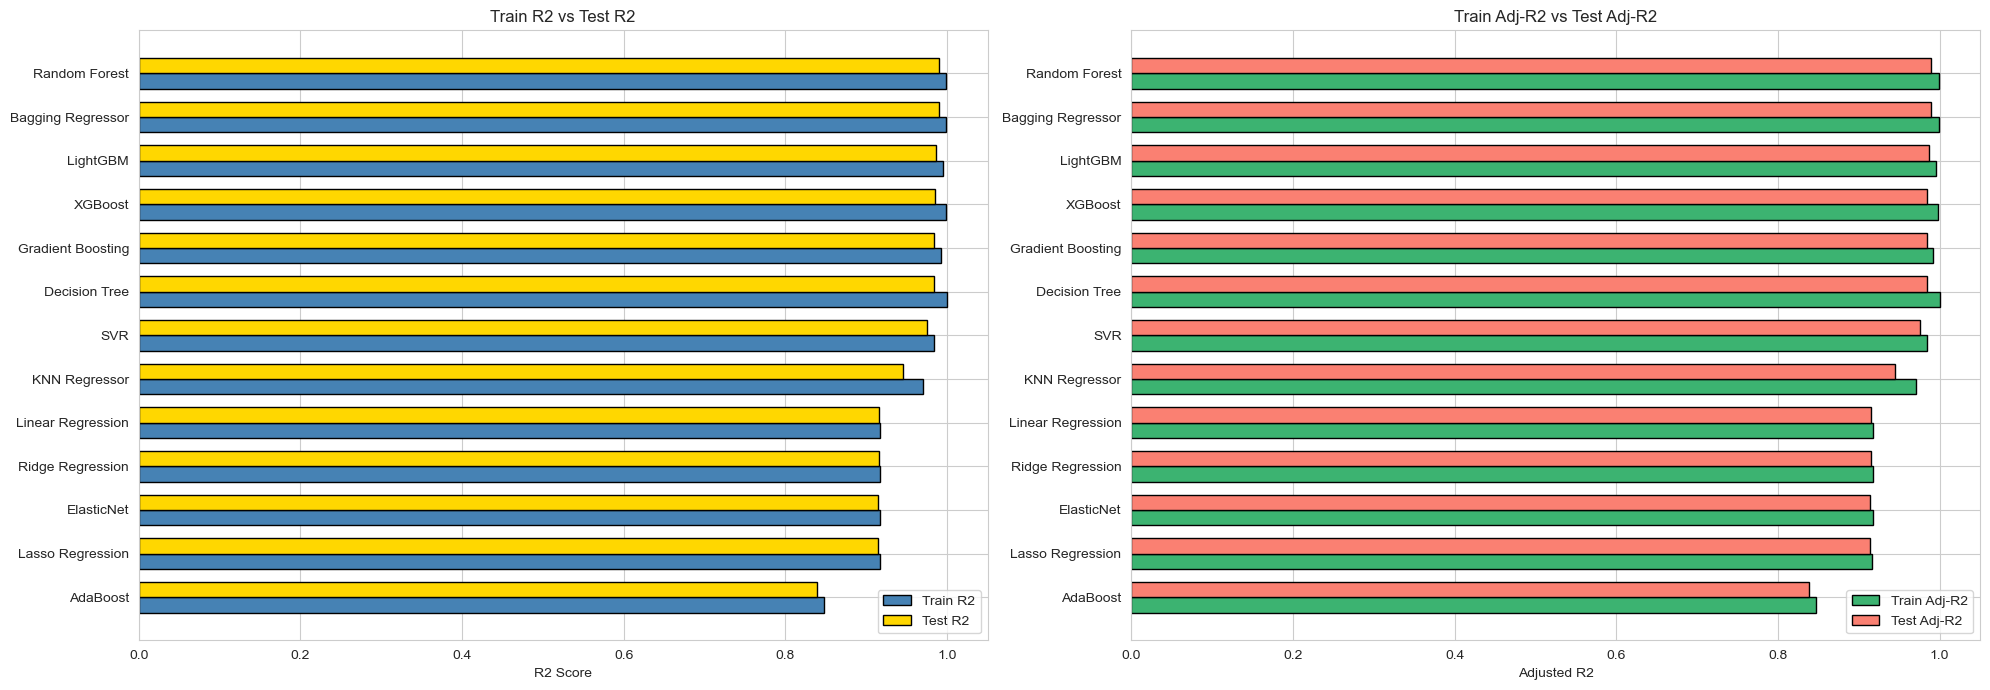

In [76]:
# Train R2 vs Test R2  |  Train AdjR2 vs Test AdjR2
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
x, w = np.arange(len(results_df)), 0.35

axes[0].barh(x+w/2, results_df['Train_R2'],  w, label='Train R2',  color='steelblue',     edgecolor='black')
axes[0].barh(x-w/2, results_df['Test_R2'],   w, label='Test R2',   color='gold',          edgecolor='black')
axes[0].set_yticks(x); axes[0].set_yticklabels(results_df['Model'])
axes[0].set_xlabel('R2 Score'); axes[0].set_title('Train R2 vs Test R2')
axes[0].legend(); axes[0].invert_yaxis()

axes[1].barh(x+w/2, results_df['Train_AdjR2'], w, label='Train Adj-R2', color='mediumseagreen', edgecolor='black')
axes[1].barh(x-w/2, results_df['Test_AdjR2'],  w, label='Test Adj-R2',  color='salmon',         edgecolor='black')
axes[1].set_yticks(x); axes[1].set_yticklabels(results_df['Model'])
axes[1].set_xlabel('Adjusted R2'); axes[1].set_title('Train Adj-R2 vs Test Adj-R2')
axes[1].legend(); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

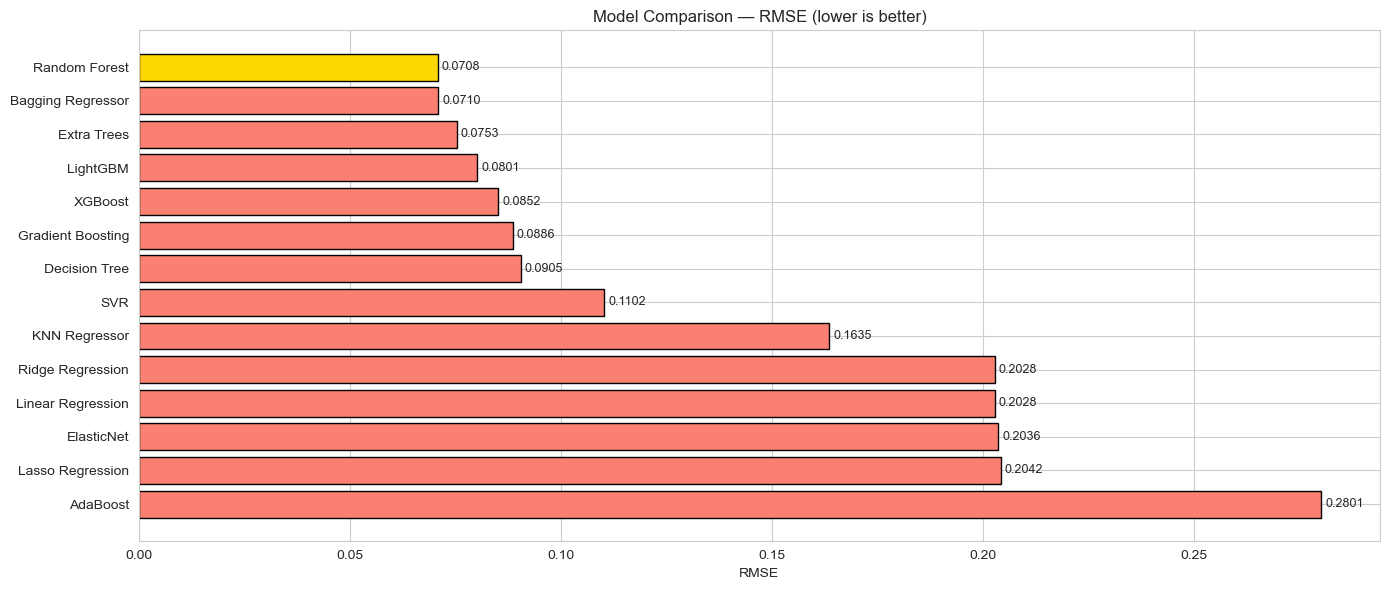


Full Comparison Table:
            Model  Train_R2  Train_AdjR2  Test_R2  Test_AdjR2    MAE   RMSE  CV_R2
    Random Forest    0.9990       0.9990   0.9897      0.9897 0.0143 0.0708 0.9910
Bagging Regressor    0.9990       0.9990   0.9896      0.9896 0.0143 0.0710 0.9910
      Extra Trees    1.0000       1.0000   0.9883      0.9883 0.0142 0.0753 0.9914
         LightGBM    0.9950       0.9950   0.9868      0.9868 0.0258 0.0801 0.9897
          XGBoost    0.9982       0.9982   0.9850      0.9850 0.0250 0.0852 0.9894
Gradient Boosting    0.9922       0.9922   0.9838      0.9838 0.0399 0.0886 0.9877
    Decision Tree    1.0000       1.0000   0.9831      0.9831 0.0201 0.0905 0.9832
              SVR    0.9835       0.9835   0.9750      0.9750 0.0635 0.1102 0.9789
    KNN Regressor    0.9706       0.9705   0.9450      0.9448 0.0834 0.1635 0.9519
 Ridge Regression    0.9175       0.9174   0.9154      0.9152 0.1396 0.2028 0.9169
Linear Regression    0.9175       0.9174   0.9154      0.9152 0

In [65]:
# RMSE comparison
rmse_df = results_df.sort_values('RMSE')
colors  = ['gold' if i == 0 else 'salmon' for i in range(len(rmse_df))]
plt.figure(figsize=(14, 6))
bars = plt.barh(rmse_df['Model'], rmse_df['RMSE'], color=colors, edgecolor='black')
for bar, val in zip(bars, rmse_df['RMSE']):
    plt.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('RMSE'); plt.title('Model Comparison — RMSE (lower is better)')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

print('\nFull Comparison Table:')
print(results_df[['Model','Train_R2','Train_AdjR2','Test_R2','Test_AdjR2','MAE','RMSE','CV_R2']].to_string(index=False))

## 13. Best Model Selection & Save PKL Files

In [77]:
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
row        = results_df.iloc[0]

print(f'Best Model    : {best_name}')
print(f'Train R2      : {row["Train_R2"]}')
print(f'Train Adj-R2  : {row["Train_AdjR2"]}')
print(f'Test  R2      : {row["Test_R2"]}')
print(f'Test  Adj-R2  : {row["Test_AdjR2"]}')
print(f'RMSE          : {row["RMSE"]}')
print(f'MAE           : {row["MAE"]}')

Best Model    : Random Forest
Train R2      : 0.999
Train Adj-R2  : 0.999
Test  R2      : 0.9896
Test  Adj-R2  : 0.9896
RMSE          : 0.0712
MAE           : 0.0143


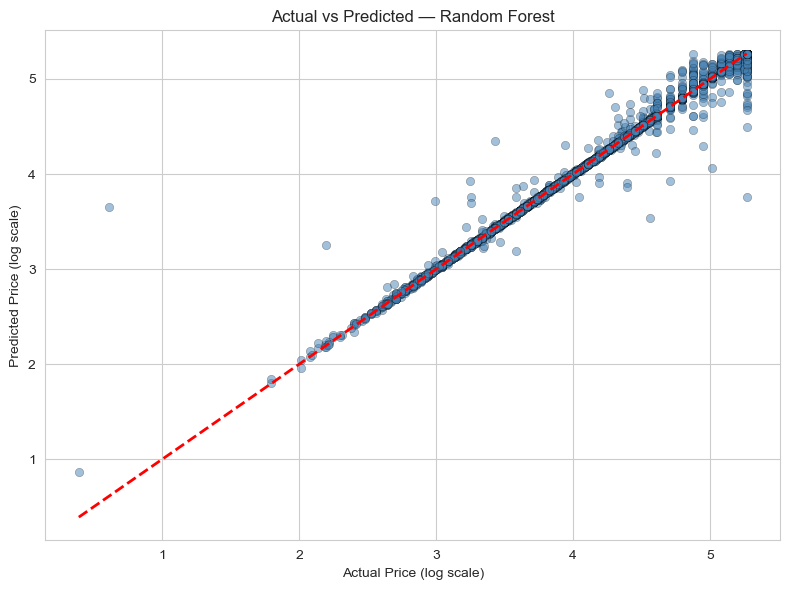

In [67]:
# Actual vs Predicted
y_pred_best = best_model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (log scale)'); plt.ylabel('Predicted Price (log scale)')
plt.title(f'Actual vs Predicted — {best_name}')
plt.tight_layout(); plt.show()

In [80]:
os.makedirs('pkl_files', exist_ok=True)

pkls = {
    'pkl_files/best_model.pkl'      : best_model,
    'pkl_files/scaler.pkl'          : scaler,
    'pkl_files/feature_columns.pkl' : X.columns.tolist(),
    'pkl_files/label_encoder.pkl'   : le,
    'pkl_files/city_target_enc.pkl' : city_target_mean.to_dict(),
    'pkl_files/city_freq_enc.pkl'   : city_freq.to_dict(),
    'pkl_files/global_mean.pkl'     : global_mean,
    'pkl_files/model_results.pkl'   : results_df,
}

for path, obj in pkls.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved: {path}')

print('\nAll PKL files saved successfully!')

Saved: pkl_files/best_model.pkl
Saved: pkl_files/scaler.pkl
Saved: pkl_files/feature_columns.pkl
Saved: pkl_files/label_encoder.pkl
Saved: pkl_files/city_target_enc.pkl
Saved: pkl_files/city_freq_enc.pkl
Saved: pkl_files/global_mean.pkl
Saved: pkl_files/model_results.pkl

All PKL files saved successfully!


In [79]:
print(X.columns)

Index(['RERA', 'BHK_NO.', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE',
       'LATITUDE', 'PRICE_PER_SQFT', 'IS_BHK', 'POSTED_BY_ENC',
       'CITY_TARGET_ENC', 'CITY_FREQ_ENC'],
      dtype='object')
